In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score)


In [17]:
df = pd.read_csv('insurance.csv')
display(df.info)

<bound method DataFrame.info of       age     sex     bmi  children smoker     region      charges
0      19  female  27.900         0    yes  southwest  16884.92400
1      18    male  33.770         1     no  southeast   1725.55230
2      28    male  33.000         3     no  southeast   4449.46200
3      33    male  22.705         0     no  northwest  21984.47061
4      32    male  28.880         0     no  northwest   3866.85520
...   ...     ...     ...       ...    ...        ...          ...
1333   50    male  30.970         3     no  northwest  10600.54830
1334   18  female  31.920         0     no  northeast   2205.98080
1335   18  female  36.850         0     no  southeast   1629.83350
1336   21  female  25.800         0     no  southwest   2007.94500
1337   61  female  29.070         0    yes  northwest  29141.36030

[1338 rows x 7 columns]>

In [18]:
display(df.columns,df.dtypes)


Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='str')

age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object

In [29]:
display(((~df.isnull()).mean())*100)

age         100.0
sex         100.0
bmi         100.0
children    100.0
smoker      100.0
region      100.0
charges     100.0
dtype: float64

In [4]:
col = ['age','bmi','children','charges']
per_zeros = ((df[col] == 0).mean())*100
display(per_zeros)

age          0.000000
bmi          0.000000
children    42.899851
charges      0.000000
dtype: float64

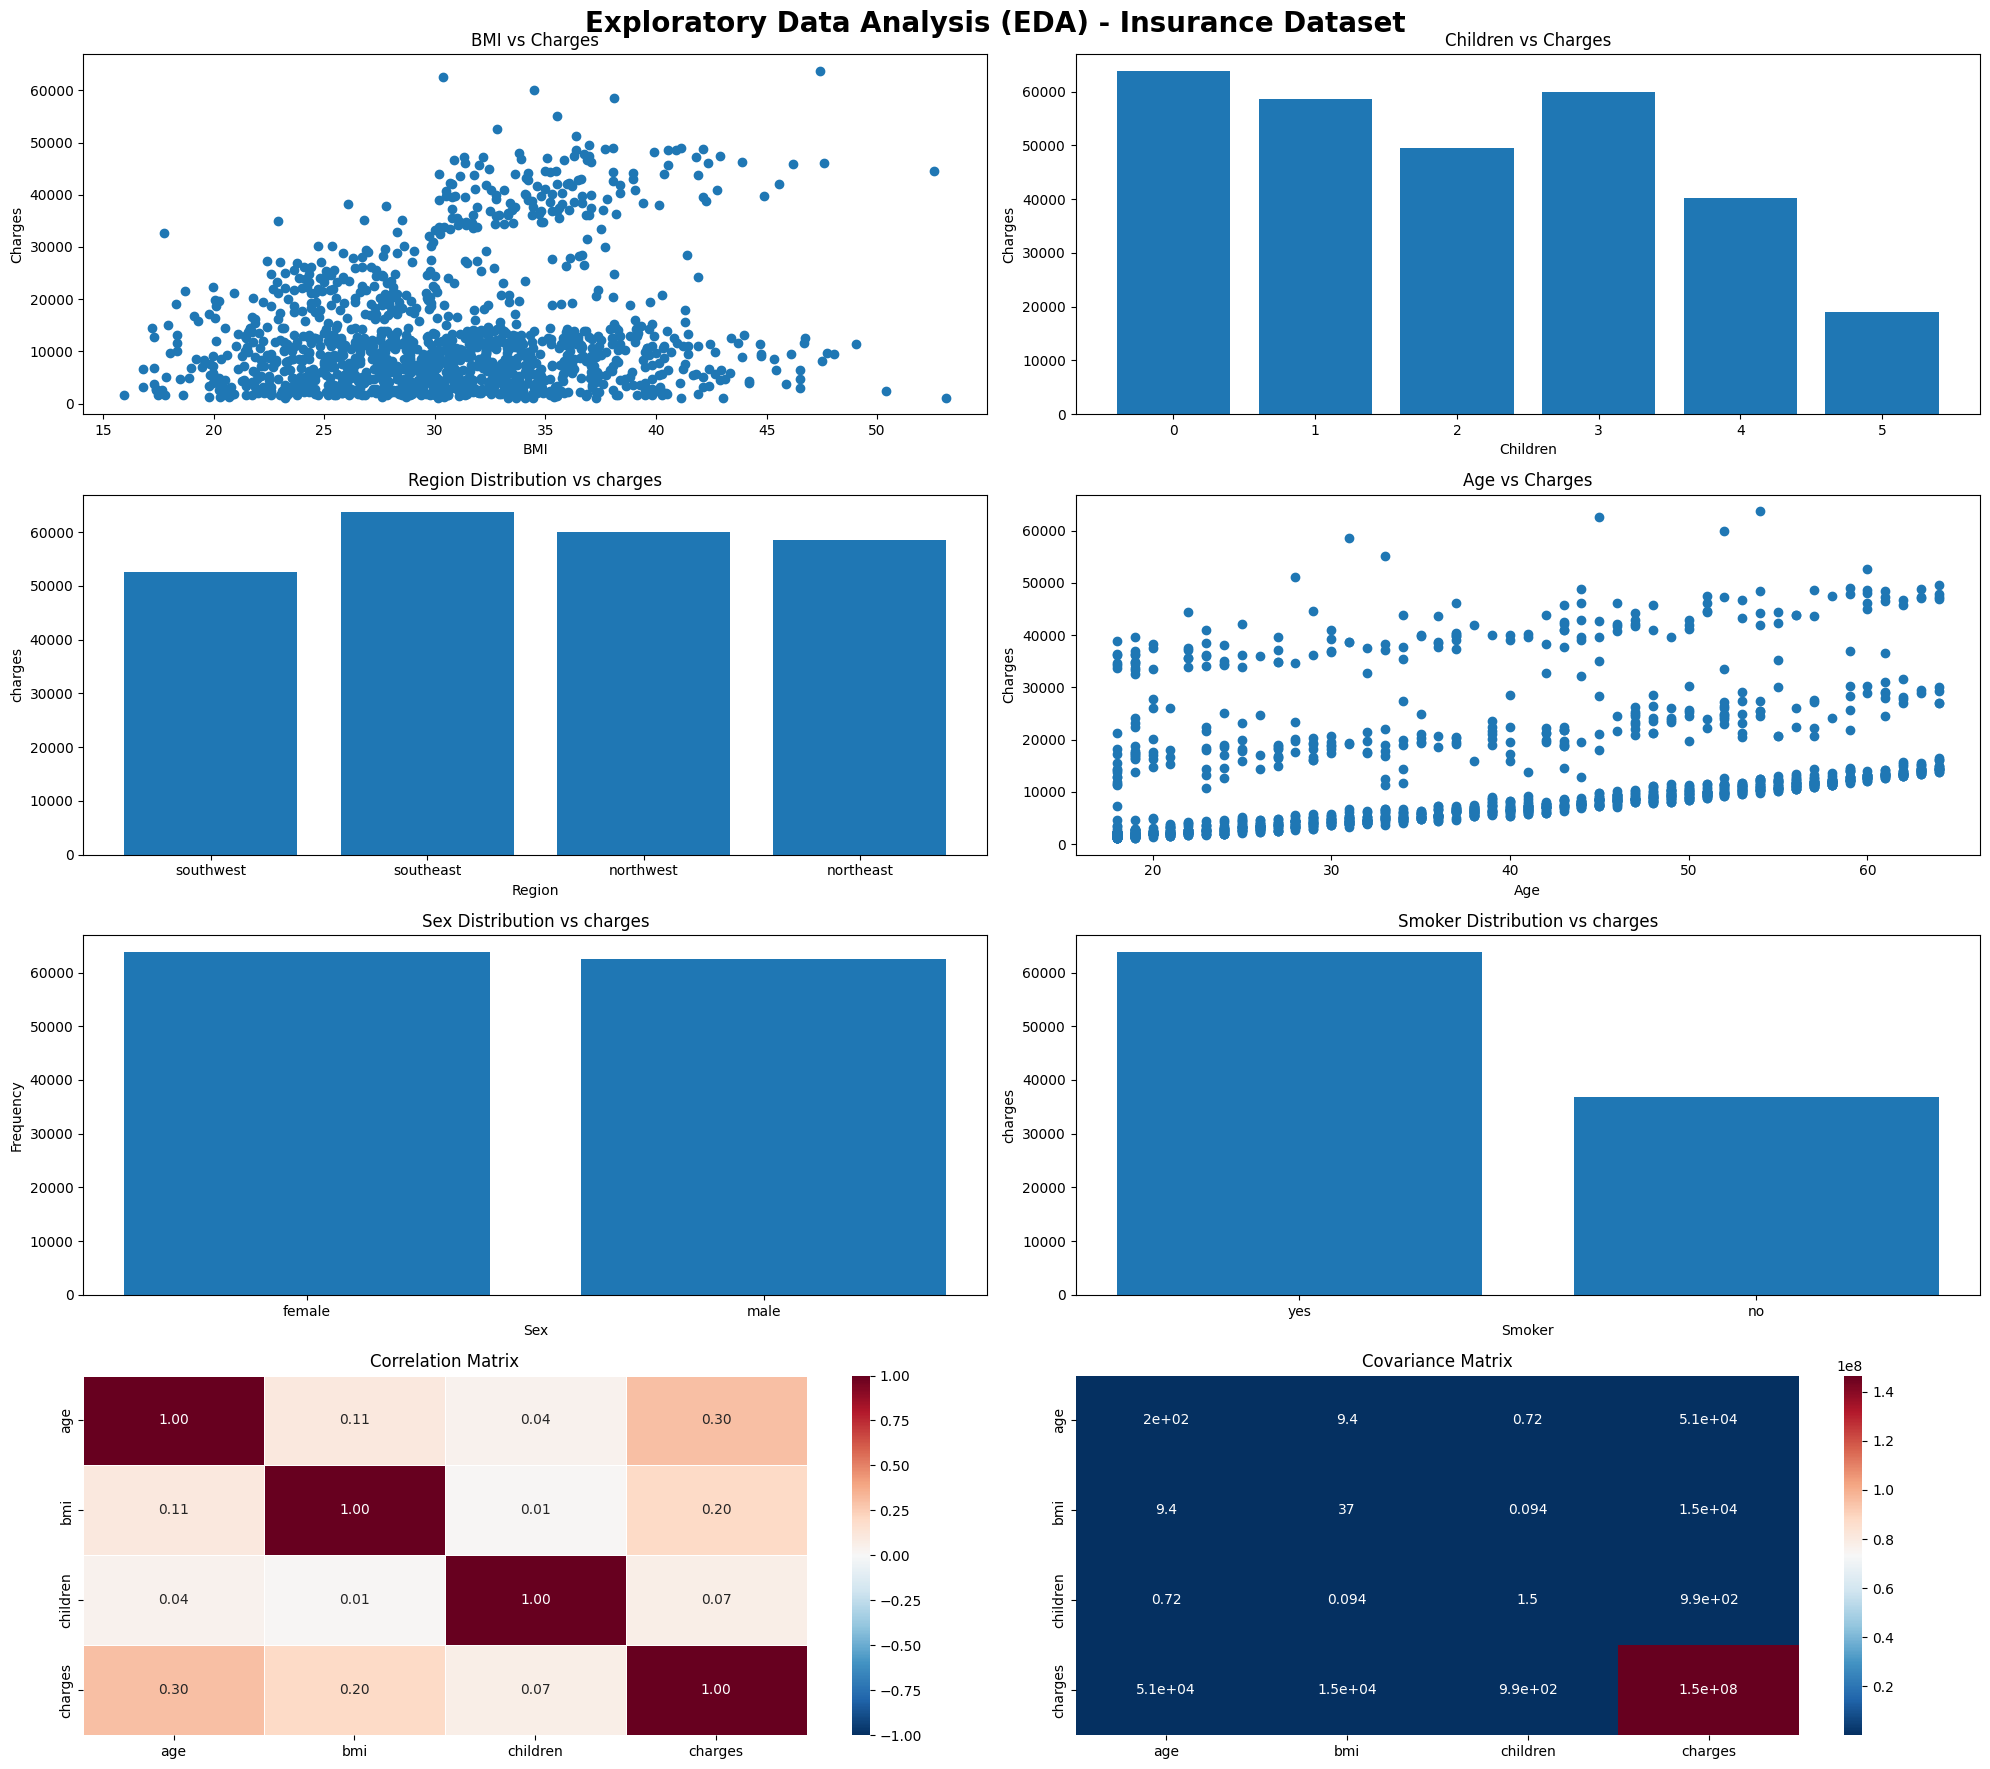

In [31]:

corr_matrix = df.corr(numeric_only=True)
df_nums=df.select_dtypes(include=np.number)
cov = np.cov(df_nums.T)
cov_matrix = pd.DataFrame(cov,index=df_nums.columns,columns=df_nums.columns)

fig, axes = plt.subplots(4, 2, figsize=(20, 18))


axes[0,0].scatter(df['bmi'], df['charges'])
axes[0,0].set_title("BMI vs Charges")
axes[0,0].set_xlabel("BMI")
axes[0,0].set_ylabel("Charges")

axes[0,1].bar(df['children'], df['charges'])
axes[0,1].set_title("Children vs Charges")
axes[0,1].set_xlabel("Children")
axes[0,1].set_ylabel("Charges")


axes[1,0].bar(df['region'],df['charges'])
axes[1,0].set_title("Region Distribution vs charges")
axes[1,0].set_xlabel("Region")
axes[1,0].set_ylabel("charges")

axes[1,1].scatter(df['age'], df['charges'])
axes[1,1].set_title("Age vs Charges")
axes[1,1].set_xlabel("Age")
axes[1,1].set_ylabel("Charges")

axes[2,0].bar(df['sex'],df['charges'])
axes[2,0].set_title("Sex Distribution vs charges")
axes[2,0].set_xlabel("Sex")
axes[2,0].set_ylabel("Frequency")

axes[2,1].bar(df['smoker'],df['charges'])
axes[2,1].set_title("Smoker Distribution vs charges")
axes[2,1].set_xlabel("Smoker")
axes[2,1].set_ylabel("charges")

sns.heatmap(corr_matrix, annot=True, fmt='.2f',
            cmap='RdBu_r', vmin=-1, vmax=1,
            linewidths=0.5, ax=axes[3,0])
axes[3,0].set_title("Correlation Matrix")

sns.heatmap(cov_matrix, annot=True,
            cmap='RdBu_r',
            ax=axes[3,1])
axes[3,1].set_title("Covariance Matrix")


fig.suptitle("Exploratory Data Analysis (EDA) - Insurance Dataset",
             fontsize=20, fontweight='bold')

plt.tight_layout()
plt.show()

## Exploratory Data Analysis (EDA)
Before building our regression models, we must understand the underlying patterns, distributions, and relationships within the insurance dataset.

## Technical Insights:
Target Variable Distribution: The scatter plots for Age vs Charges and BMI vs Charges reveal clear stratification. In Age vs Charges, we see three distinct "bands" of costs, suggesting that factors other than age (likely smoking status) drastically shift the base cost.

## Categorical Impact: 
The bar charts indicate that Smokers incur significantly higher charges than non-smokers. Region and Sex appear to have a more uniform distribution regarding total charges.

## Correlation Analysis: 
The Correlation Matrix highlights a moderate positive correlation (0.30) between Age and Charges. However, since correlation only captures linear relationships, the "Smoker" categorical variable (which we will encode next) is expected to be a much stronger predictor.

## Covariance:
 The Covariance Matrix shows how variables change together in their original scales, emphasizing the high variance in medical Charges.

## Data Preprocessing:
- Encoding Categorical Variables
Machine Learning models require numerical input. Since our dataset contains categorical variables (sex, smoker, region), we must transform them into a format the model can interpret.

- Decision Logic:
- One-Hot Encoding: We applied One-Hot Encoding to convert categorical labels into binary columns.

- Handling the Dummy Variable Trap: We used drop='first' to avoid Multicollinearity. For binary columns like sex and smoker, this reduces them to a single column (e.g., smoker_yes), where 0 represents the dropped category.

- Target Separation: We isolated charges into a df_target series to define our dependent variable (y) for the regression task, while keeping the independent variables (X) in the main dataframe.

In [19]:
from sklearn.preprocessing import OneHotEncoder

enc = OneHotEncoder(sparse_output=False, drop='first')

df_enc = enc.fit_transform(df[['sex','smoker','region']])

df_enc = pd.DataFrame(df_enc,columns = enc.get_feature_names_out(['sex','smoker','region']))
df = df.merge(df_enc, left_index=True, right_index=True)
df_target = df['charges']
df.drop(columns=['sex','smoker','region','charges'], inplace=True)

display(df.head())

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
0,19,27.900,0,0.0,1.0,0.0,0.0,1.0
1,18,33.770,1,1.0,0.0,0.0,1.0,0.0
2,28,33.000,3,1.0,0.0,0.0,1.0,0.0
3,33,22.705,0,1.0,0.0,1.0,0.0,0.0
4,32,28.880,0,1.0,0.0,1.0,0.0,0.0


Scaling the data before fitting

In [6]:
# splitting the data
x_train , x_test , y_train , y_test = train_test_split(df,df_target,test_size=0.2,random_state=42)

# scalling the data
scale = StandardScaler()
x_train_scaled = scale.fit_transform(x_train)
x_test_scaled = scale.transform(x_test)

# training the model
model = LinearRegression()
model.fit(x_train_scaled,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Testing the model

In [ ]:
#MSE
y_pred = model.predict(x_test_scaled)
mse = mean_squared_error(y_test, y_pred)    

#RMSE
rmse = np.sqrt(mse)

#R2 Score
r2 = r2_score(y_test, y_pred)   

display(f"Mean Squared Error: {mse:.2f}")
display(f"Root Mean Squared Error: {rmse:.2f}") 
display(f"R2 Score: {r2:.2f}") 

'Mean Squared Error: 33596915.85'

'Root Mean Squared Error: 5796.28'

'R2 Score: 0.78'

## Capturing Non-Linearity with Polynomial Regression
Our EDA showed stratified "bands" in the data, suggesting that the relationship between features (like Age and BMI) and Charges might be non-linear or involve interactions.

- Decision Logic:
Polynomial Expansion: We used PolynomialFeatures(degree=2) to create interaction terms (e.g., Age×BMI) and squared terms. This allows the model to fit a curved surface rather than a flat plane.

- Pipeline Implementation: To ensure a clean workflow and prevent data leakage, we encapsulated the transformation and regression into a Pipeline. This ensures that features are only transformed during the appropriate training phase of each cross-validation fold.

- Cross-Validation (CV=10): Instead of relying on a single train/test split, we used 10-fold CV. This provides a more robust estimate of how the model will generalize to unseen data, reducing the risk of reporting an "overfitted" score.

- The Coming Decision (Next Step):
Based on your current results, your next logical move is Model Comparison or Regularization.

In [29]:
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score


poly_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('regressor', LinearRegression())
])

# 2. Apply Cross-Validation
scores = cross_val_score(poly_pipeline, x_train_scaled, y_train, cv=10, scoring='r2',n_jobs=-1)

print(f"Polynomial CV R2 Scores: {scores}")
print(f"Average R2: {scores.mean():.4f}")


Polynomial CV R2 Scores: [0.8460687  0.80516792 0.90203366 0.88879641 0.83784874 0.73937884
 0.75026034 0.76685695 0.86578044 0.84739008]
Average R2: 0.8250


## Model Expansion: Ensembles and Hyperparameter Tuning
While the Polynomial Regression increased our average R 2to 0.825, the variation in CV scores (ranging from 0.73 to 0.90) suggests the model is sensitive to specific data splits. To achieve a more stable and accurate prediction, we explore Ensemble Methods and Instance-based Learning.

- Technical Insights:
Random Forest Regressor: By training multiple decision trees on different bootstrap samples and averaging their predictions, we aim to reduce the variance that plagued our polynomial model.

- K-Nearest Neighbors (KNN): This serves as a non-parametric baseline that predicts charges based on the similarity (distance) between individuals in the feature space.

- GridSearchCV Strategy: We implemented an exhaustive search over a multi-dimensional parameter grid. This ensures we aren't just using "default" settings but are finding the mathematical sweet spot for this specific insurance data.

In [28]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.model_selection import GridSearchCV


reg_models = {
    'forest': RandomForestRegressor(),
    'knn': KNeighborsRegressor()
}


reg_para = {
    'forest': {
        'n_estimators': [100, 150, 200, 250],
        'max_features' : ['sqrt', 'log2', 0.3, 0.5],
        'max_depth': [5, 10, 15, 20],
        'min_samples_leaf': [1,2,3],
        'min_samples_split': [1,2],
        'ccp_alpha' :[0.0, 0.01, 0.1]
    },
    'knn': {
        'n_neighbors': [5, 6, 7, 8, 9, 10]
    }
}

#
best_models = {}

for name in reg_models:
    print(f"Searching for {name}...")
    grid_search = GridSearchCV(
        estimator=reg_models[name], 
        param_grid=reg_para[name], 
        n_jobs=-1, 
        cv=5,
        scoring='r2' 
    )
    
    grid_search.fit(x_train_scaled, y_train)
    best_models[name] = grid_search.best_estimator_
    print(f"Best score for {name}: {grid_search.best_score_}")
    print(f"Best parameters for {name}: {grid_search.best_params_}\n")



Searching for forest...


c:\Users\romma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
2880 fits failed out of a total of 5760.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
2880 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\romma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\romma\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\base.py", line 1329, in wrapper
    estimator._validate_params()
    ~~~~~~~~~~~~~~~~~~~~~~~~~~^^
  File 

Best score for forest: 0.8472201326031692
Best parameters for forest: {'ccp_alpha': 0.0, 'max_depth': 5, 'max_features': 0.5, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}

Searching for knn...
Best score for knn: 0.7734912872630858
Best parameters for knn: {'n_neighbors': 9}



## Final Conclusion & Business Impact
The objective of this project was to predict medical insurance charges based on demographic and lifestyle factors.

- Key Findings:
Non-Linearity is Key: The jump from a Linear baseline (0.78) to a Random Forest (0.847) proves that the interaction between features—specifically the relationship between BMI and Smoking status—is the primary driver of insurance costs.

- Model Robustness: Through 5-fold Cross-Validation and Hyperparameter tuning, we ensured that our model is not just accurate on our training data but is generalizable to new patients.

- Feature Drivers: Based on our exploration and model coefficients, Lifestyle (Smoking) and Age are the most influential variables, while Region and Sex have minimal impact on the final charge.

- Next Steps for Deployment:
Residual Analysis: Investigate where the 15% of unexplained variance is coming from. Are there specific edge cases (e.g., rare chronic conditions) the model is missing?

- Feature Engineering: Exploring a "BMI Category" (Underweight, Normal, Obese) to see if discretization helps the model further segment risk groups.